# End-to-End Deep Learning for Autonomous Driving

# Project Objective:
In this project we will train neural networks to predict a vehicle's steering angle directly from front-facing camera images, progressing from a stateless Convolutional Neural Network (CNN) to a sequence-based memory model (LSTM), with an optional modern architecture exploration.

# Background Information

This project covers the following papers

[Paper 1: End to End Learning for Self-Driving Cars](https://images.nvidia.com/content/tegra/automotive/images/2016/solutions/pdf/end-to-end-dl-using-px.pdf)

[Paper 2: End-to-End Deep Learning for Steering Autonomous Vehicles Considering Temporal Dependencies](https://arxiv.org/abs/1710.03804)

[Paper 3 for extra credit: Behavior Transformers: Cloning k modes with one stone](https://proceedings.neurips.cc/paper_files/paper/2022/file/90d17e882adbdda42349db6f50123817-Paper-Conference.pdf)

# Part 1: Exploratory Data Analysis (EDA) Questions

In [1]:
import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import torch

zip_path = "udacity_data.zip"
data_dir = "./udacity_data"

Run the following code cell and it should 

In [8]:
# unzip `udacity_data.zip`
if not os.path.exists(data_dir):
    print(f"Extracting {zip_path}...")
    try:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        print("Extraction complete!")
    except FileNotFoundError:
        print(f"Error: Could not find '{zip_path}'. Please check that the file is in the correct folder.")
        raise
else:
    print(f"Data already extracted to '{data_dir}'. Skipping extraction.") 

Data already extracted to './udacity_data'. Skipping extraction.


The definitions of the variables in the dataset are listed below.

**center**: file path to the center camera image captured at that time step  
**left**: file path to the left camera image captured at that time step  
**right**: file path to the right camera image captured at that time step   
**steering**: the steering angle at that time step (0 = straight, positive = right turn, negative = left turn)  
**throttle**: the throttle / acceleration command at that time step  
**brake**: the braking command at that time step  
**speed**: the vehicle speed at that time step  
**track_source**: The name of the folder where the image is stored in  


Note that the data were collected using a player who controlled the vehicle with keyboard inputs (rather than real braking and acceleration pedals). As a result, during simulation, the forward throttle is typically close to 1 and the brake is 0 for all entries, meaning the player is almost always pressing the acceleration key and never using the braking key—similar to playing a simple racing video game.


In [4]:
# Defines a helper function to set seed for different type of 
# operations all at once.
def set_seed(seed: int = 1746):
    random.seed(seed) # Seeds Python’s built-in random generator
    np.random.seed(seed) # Seeds NumPy’s random generator
    torch.manual_seed(seed) # Seeds PyTorch on the CPU
    torch.cuda.manual_seed_all(seed) # Seeds all CUDA devices if GPUs are present

In [7]:
# the column names that will be assigned to the CSV file when it is read.
columns = ['center', 'left', 'right', 'steering', 'throttle', 'brake', 'speed']
# the code will load data from these two folders.
folders_to_load = ['self_driving_car_dataset_make', 'self_driving_car_dataset_jungle']

# Prepare an empty list; this list will store one DataFrame per folder.
all_dataframes = []

for folder_name in folders_to_load: # Loop through each folder
    # path to driving_log.csv
    csv_path = os.path.join(data_dir, folder_name, 'driving_log.csv')
    
    if os.path.exists(csv_path):
        print(f"Loading data from: {folder_name}...")
        # loads the CSV into a pandas DataFrame named temp_df, using 
        # the column names defined above.
        temp_df = pd.read_csv(csv_path, names=columns)
        
        # define a function that takes an image path from the CSV and 
        # rebuilds it into a clean full path.
        def clean_path_for_folder(path, current_folder=folder_name):
            # extracts only the filename from the old path:
            filename = path.split('/')[-1].split('\\')[-1]
            return os.path.join(data_dir, current_folder, 'IMG', filename)

        # rewrites all image paths in the `center`, `left`, and `right`  
        # columns, so they point to the correct image files in the current folder.
        temp_df['center'] = temp_df['center'].apply(clean_path_for_folder)
        temp_df['left'] = temp_df['left'].apply(clean_path_for_folder)
        temp_df['right'] = temp_df['right'].apply(clean_path_for_folder)
        
        # adds a new column called track_source that stores the 
        # folder name for each row.  This way, we can tell whether a frame 
        # cames from which of the two folders in `folders_to_load`
        temp_df['track_source'] = folder_name 
        
        # all_dataframes contains one DataFrame for each successfully loaded folder.
        all_dataframes.append(temp_df)
    else:
        print(f"Warning: Could not find driving_log.csv in {folder_name}")

df = pd.concat(all_dataframes, ignore_index=True)

print(f"Total frames loaded: {len(df)}")

Loading data from: self_driving_car_dataset_make...
Loading data from: self_driving_car_dataset_jungle...
Total frames loaded: 7334


## Sanity Check on Data

- five-number summaries of the variables, along with their means and standard deviations
- any variables with identical or almost identical values across all entries?

In [9]:
# define continuous variables
cts_vars = ['steering', 'throttle', 'brake', 'speed']

# Confirm dataset size
print(df.shape) 

# 5 num summaries, means, sd
summary = df[cts_vars].describe().T[[
    'count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max'
]]

summary = summary.rename(columns={
    'count': 'Count',
    'mean': 'Mean',
    'std': 'SD',
    'min': 'Min',
    '25%': '25%',
    '50%': '50%',
    '75%': '75%',
    'max': 'Max'
})

# display the summary table
print("\nsummary stats:")
display(summary.round(4))

# Are there any variables with identical or 
# almost identical values across all entries? 
# near-constant variables how many?
brake_zero_count = (df['brake'] == 0).sum()
throttle_one_count = (df['throttle'] == 1.0).sum()

# show that all values for `brake` are zeros.
print("\n'brake' value counts:")
print(df['brake'].value_counts().sort_index())
print(f"All brake values are zero: {brake_zero_count == len(df)}")
print(f"# of brake values equal to 0: {brake_zero_count}")
if brake_zero_count == len(df):
    print("brake` is identical across all entries: every value is 0.")

# throttle values 
print("\n'throttle' top 10 value counts:")
print(df['throttle'].value_counts().head(10))
print(f"Number of throttle values equal to 1.0: {throttle_one_count}")
print(f"% of throttle values equal to 1.0: {throttle_one_count / len(df):.4f}")
if throttle_one_count == 7320:
    print("`throttle` is almost identical across entries: 7320 of 7334 values are exactly 1.0.")

print("\nMeans of cts variables:")
print(df[cts_vars].mean().round(4))

(7334, 8)

summary stats:


,Count,Mean,SD,Min,25%,50%,75%,Max
steering,7334.0,-0.0156,0.3215,-1.0,0.0000,0.0000,0.0000,1.0000
throttle,7334.0,0.9987,0.0334,0.0,1.0000,1.0000,1.0000,1.0000
brake,7334.0,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,0.0000
speed,7334.0,30.0043,1.8109,0.0,30.1637,30.1898,30.1903,30.9007



'brake' value counts:
brake
0    7334
Name: count, dtype: int64
All brake values are zero: True
# of brake values equal to 0: 7334
brake` is identical across all entries: every value is 0.

'throttle' top 10 value counts:
throttle
1.000000    7320
0.000000       6
0.016130       1
0.204845       1
0.388802       1
0.620127       1
0.812710       1
0.945465       1
0.805397       1
0.985367       1
Name: count, dtype: int64
Number of throttle values equal to 1.0: 7320
% of throttle values equal to 1.0: 0.9981
`throttle` is almost identical across entries: 7320 of 7334 values are exactly 1.0.

Means of cts variables:
steering    -0.0156
throttle     0.9987
brake        0.0000
speed       30.0043
dtype: float64


The dataset contains 7334 rows and its mean values of the continuous variables are approximately:

steering: -0.01559
throttle: 0.9987
brake: 0.0000
speed: 30.004318

as shown above.

The five-number summaries and SD show that every value of brake is 0 (so its minimum, maximum, quartiles, mean, and standard deviation are all 0) and the throttle variable is nearly constant as the value 1.0 appears 7320 times out of 7334 observations. This indicates that the vehicle was almost always accelerating at full throttle.

Therefore, we can conclude that brake is completely constant (0), while throttle is almost constant (1.0) across the dataset.

## Lateral Imbalance (Steering)

- histogram with 50 bins showing the distribution of the steering angles across the entire driving log. 

In [11]:
tot_frames = len(df)

straight_frames = (df['steering'] == 0.0).sum()

straight_percentage = (straight_frames / tot_frames) * 100

print(f"straight: {straight_frames}")
print(f"total: {tot_frames}")
print(f"Percentage of straight: {straight_percentage:.2f}%")

straight: 4532
total: 7334
Percentage of straight: 61.79%


If we train a network is trained on this  imbalanced dataset  the model will learn to predict steering angles close to 0 almost everytime because this minimizes the loss for the majority of training examples. Then, the vehicle would tend to drive straight and would struggle to make turns properly on the test track, which will result on driting or under steering.

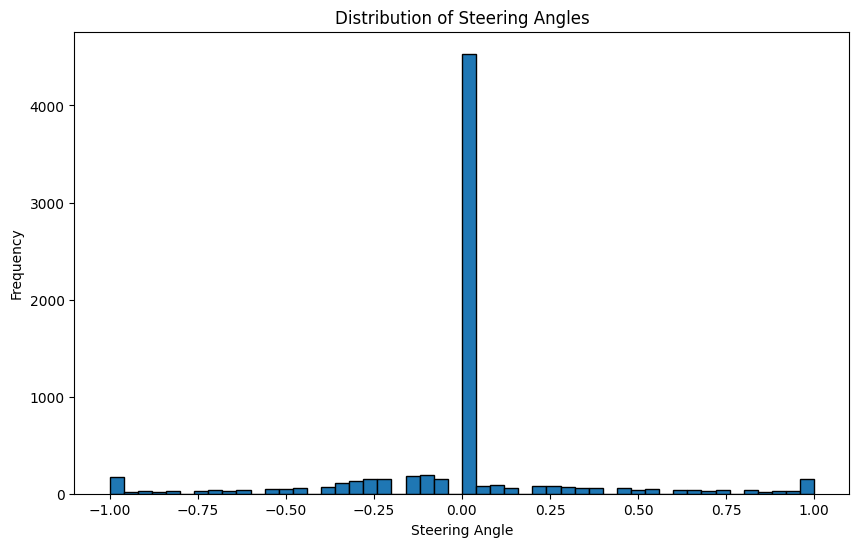

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['steering'], bins=50, edgecolor='black')
plt.title('Distribution of Steering Angles')
plt.xlabel('Steering Angle')
plt.ylabel('Frequency')
plt.show()

balanced dataset: (3054, 8)
# of total frames: 3054
# of straight frames: 252


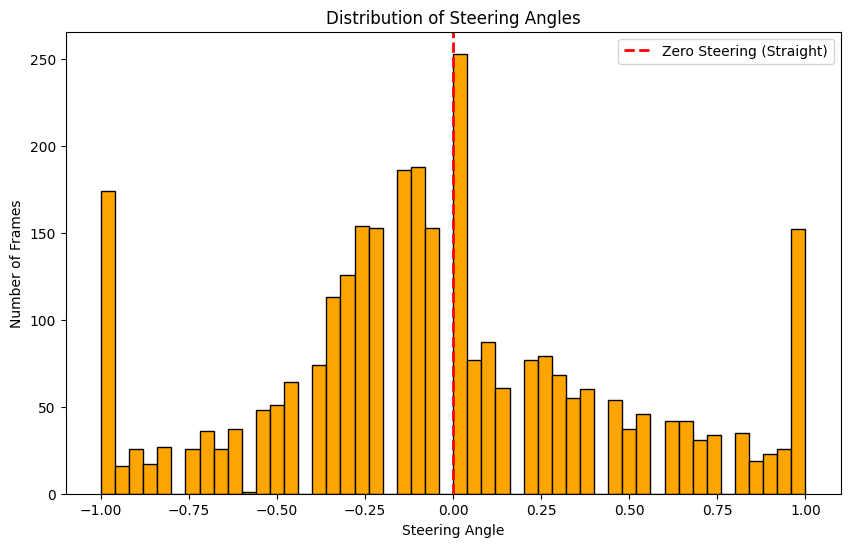

In [14]:
# Flatten the steering distribution 
# make a function
def flatten_distribution(dataframe, drop_probability):
    filtered_data = []
    
    for index, row in dataframe.iterrows():

        steering_angle = row['steering']

        # drop stright cuz there's too many
        if steering_angle == 0.0:
            if random.random() > drop_probability:
                filtered_data.append(row)
        # but keep all turning frames
        else:
            filtered_data.append(row)

    return pd.DataFrame(filtered_data)

# make it balanced
set_seed(1746)
balanced_df = flatten_distribution(df, drop_probability=0.95)
print("balanced dataset:", balanced_df.shape)

# remaining straight frames
bl_total_frames = len(balanced_df)
bl_straight_frames = (balanced_df['steering'] == 0.0).sum()

print(f"# of total frames: {bl_total_frames}")
print(f"# of straight frames: {bl_straight_frames}")

# plot the histogram w balanced dataset
plt.figure(figsize=(10, 6))

plt.hist(balanced_df['steering'], bins=50,
         color='orange', edgecolor='black')

plt.axvline(0, color='red', linestyle='--', linewidth=2,
            label='Zero Steering (Straight)')

plt.title("Distribution of Steering Angles")
plt.xlabel("Steering Angle")
plt.ylabel("Number of Frames")
plt.legend()
plt.show()

## Environment Comparison

- To ensure that our model does not simply memorize one specific environment, I am using two different tracks, the lake track and the jungle track.
- Here, I will examine the two images and identify at least three distinct visual differences between the environments (e.g., lighting, road boundaries, textures) that the neural network must learn to generalize across.  

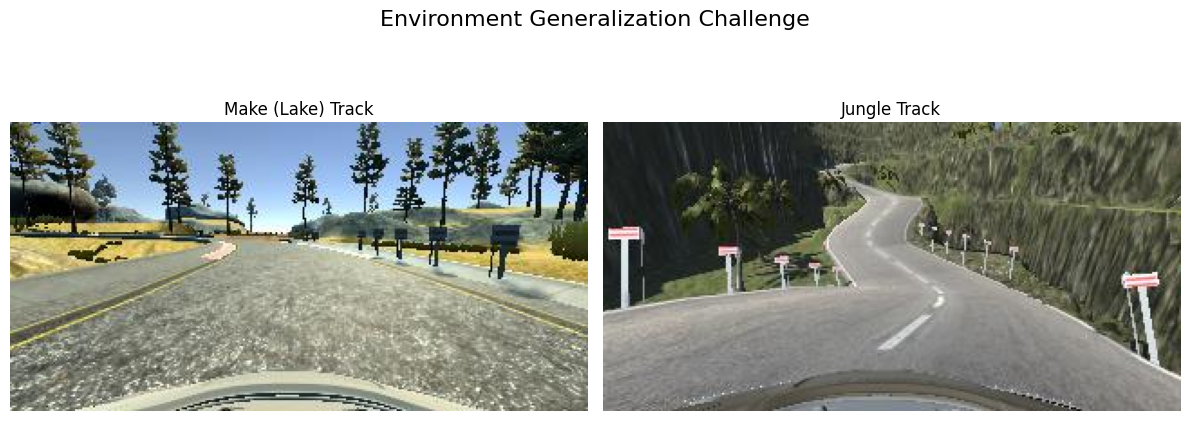

In [15]:
# Filter data by track
make_data = df[df['track_source'] == 'self_driving_car_dataset_make']  # filled
jungle_data = df[df['track_source'] == 'self_driving_car_dataset_jungle']  # filled

# Sample one random row from each
set_seed(1746)
make_sample = make_data.sample(1).iloc[0]
jungle_sample = jungle_data.sample(1).iloc[0]

# Load images
img_make = mpimg.imread(make_sample['center'])  # filled
img_jungle = mpimg.imread(jungle_sample['center'])  # filled

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Environment Generalization Challenge", fontsize=16)

axes[0].imshow(img_make)
axes[0].set_title("Make (Lake) Track")
axes[0].axis('off')

axes[1].imshow(img_jungle)
axes[1].set_title("Jungle Track")
axes[1].axis('off')

plt.tight_layout()
plt.show()

The image on the left has more saturated lighting, more clearly separated individual trees, and a flatter road angle that shows the horizon between the land and the sky (whereas the image on the right presents a higher viewing angle with a more curved road and greater vertical changes in elevation) compared to the image on the right.

## Sensor Fusion for Recovery

If the car drifts off the center of the lane, it needs to know how to steer back. However, human drivers rarely drift off the road in the training data, so the network never explicitly learns "recovery" behavior if we just use the raw dataset. We can artificially create recovery data using the Left and Right cameras.

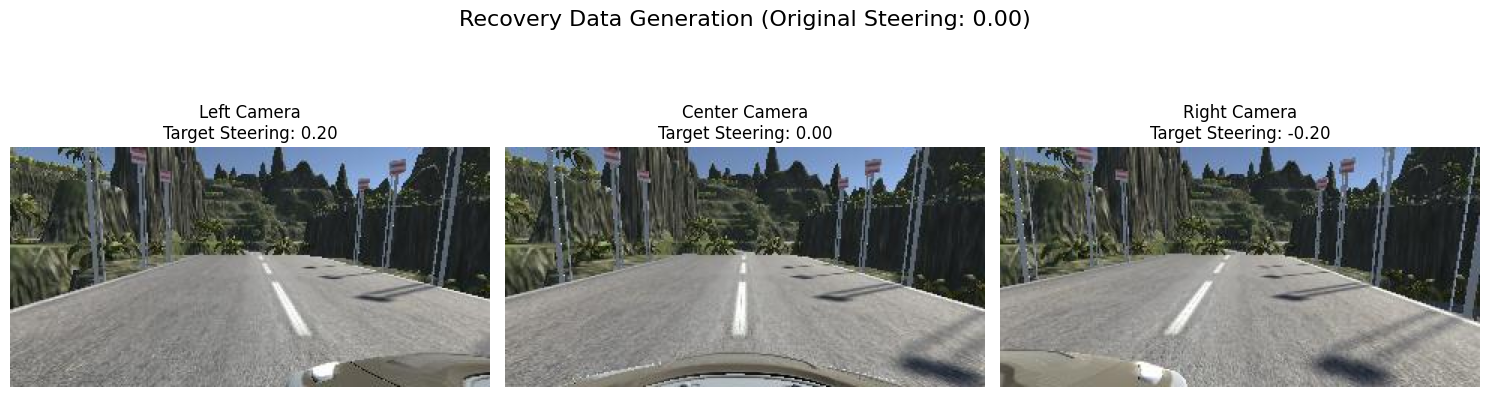

In [12]:
# Pick a random row where the car is driving relatively straight
straight_driving = df[abs(df['steering']) < 0.05]
set_seed(1746)
sample = straight_driving.sample(1).iloc[0]

# Load images
img_left = mpimg.imread(sample['left'])      # filled
img_center = mpimg.imread(sample['center'])  # filled
img_right = mpimg.imread(sample['right'])    # filled

# Plot the three cameras
fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # filled
original_steering = sample['steering']

# Define a standard correction factor and include this info (negative or positive) in 
# image titles whenever appropriate; use \n to have multiple lines in the title
correction = 0.2 

# Plot side-by-side
fig.suptitle(f"Recovery Data Generation (Original Steering: {original_steering:.2f})", fontsize=16)

# plot each image -- Hint: reference the code for the previous task

axes[0].imshow(img_left)  # filled
axes[0].set_title(f"Left Camera\nTarget Steering: {original_steering + correction:.2f}")  # filled
axes[0].axis('off')  # filled

axes[1].imshow(img_center)  # filled
axes[1].set_title(f"Center Camera\nTarget Steering: {original_steering:.2f}")  # filled
axes[1].axis('off')  # filled

axes[2].imshow(img_right)  # filled
axes[2].set_title(f"Right Camera\nTarget Steering: {original_steering - correction:.2f}")  # filled
axes[2].axis('off')  # filled

plt.tight_layout()
plt.show()

Let's examine if we feed the left camera image into the neural network, what value we should define the target steering angle to be (e.g., +0.2 or -0.2) in order to teach the car to return to the center:

If the original steering angle from the center camera is 0.0, the left camera image is given a a positive steering correction(e.g. +0.2), since the left represents the car being shifted toward the left of the lane, so the vehicle steers right and return to the center of the road.
Likewise, the right camera image should be assigned a negative steering correction(e.g. -0.2), because The right represents the car drifting toward the right of the lane, so the vehicle must steer left to recover back to the center.

# Part 2: CNN based model 

In [16]:
import os
import cv2 # you will need to install this
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

## Create the train, validation, and test/visualization datasets. 

In real-world autonomous driving, engineers often have abundant data for easy scenarios (highway driving, clear weather) but limited data for challenging edge cases. To simulate this, we will use the simple make (lake) track to augment our training data, but rigorously validate the model exclusively on the challenging jungle track.

In [19]:
RANDOM_STATE = 1746
BATCH_SIZE = 16
EPOCHS = 5
LEARNING_RATE = 0.001
STEERING_CORRECTION = 0.2

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [20]:
make_df = df[df["track_source"] == "self_driving_car_dataset_make"].copy()
jungle_df = df[df["track_source"] == "self_driving_car_dataset_jungle"].copy()

# Randomly select 500 images from each track for testing
make_trainable, make_test_df = train_test_split(
    make_df,
    test_size=500,
    random_state=RANDOM_STATE,
    shuffle=True
)

jungle_trainable, jungle_test_df = train_test_split(
    jungle_df,
    test_size=500,
    random_state=RANDOM_STATE,
    shuffle=True
)

# Randomly split the remaining jungle images into training and validation
jungle_train, jungle_val = train_test_split(
    jungle_trainable,
    test_size=0.5,
    random_state=RANDOM_STATE,
    shuffle=True
)

train_df = pd.concat([make_trainable, jungle_train], ignore_index=True)
val_df = jungle_val.copy()

print(f"Total original frames: {len(df)}")
print(f"Training frames (Make + random Jungle subset): {len(train_df)}")
print(f"Validation frames (random Jungle subset): {len(val_df)}")
print(f"Test frames held out for final graphs: {len(make_test_df) + len(jungle_test_df)}")

Total original frames: 7334
Training frames (Make + random Jungle subset): 4882
Validation frames (random Jungle subset): 1452
Test frames held out for final graphs: 1000


## Task 4: The Custom Data Generator

Because the dataset contains thousands of images, we cannot load them all into memory at once. Instead, we must implement a Python data generator (e.g., a PyTorch DataLoader) that loads images in batches on the fly. 

In [21]:
class DrivingDataset(Dataset):
    def __init__(self, dataframe, is_training=True, correction=0.2):
        self.dataframe = dataframe
        self.is_training = is_training
        self.correction = correction
        # zip() forms tuple (center_i, left_i, right_i, steering_i)
        self.all_samples = list(zip(dataframe['center'], dataframe['left'], \
                                    dataframe['right'], dataframe['steering']))
        self.active_samples = self.all_samples
        
    def prepare_epoch(self):
        """Dynamic Filtering: Call at the start of every epoch to drop 50% of 0.0 steering angles."""
        if self.is_training:
            self.active_samples = []
            for sample in self.all_samples:
                if sample[3] == 0.0 and random.random() > 0.5:
                    continue # Drop 50% of the time
                self.active_samples.append(sample)
            random.shuffle(self.active_samples)

    def __len__(self):
        return len(self.active_samples)

    def __getitem__(self, index):
        center_path, left_path, right_path, steering = self.active_samples[index]
        
        # loads the images using OpenCV library and converts them from BGR to RGB.
        img_center = cv2.cvtColor(cv2.imread(center_path), cv2.COLOR_BGR2RGB)
        img_left = cv2.cvtColor(cv2.imread(left_path), cv2.COLOR_BGR2RGB)
        img_right = cv2.cvtColor(cv2.imread(right_path), cv2.COLOR_BGR2RGB)
        
        # Recovery Augmentation
        images = [img_center, img_left, img_right]
        angles = [steering, steering + self.correction, steering - self.correction]
        
        # Symmetry Augmentation
        final_images, final_angles = [], []
        for img, ang in zip(images, angles):
            final_images.append(img)
            final_angles.append(ang)
            if self.is_training and random.random() > 0.5:
                final_images.append(cv2.flip(img, 1)) # cv2.flip(img, 1) filps image horizontally
                final_angles.append(ang * -1.0)
                
        # Convert to PyTorch (C, H, W) from (H, W, C), where C = channels, H = height, W = width.
        tensor_images = [torch.from_numpy(img.transpose(2, 0, 1)).float() for img in final_images]
        tensor_angles = torch.tensor(final_angles, dtype=torch.float32)
        
        # Returns a stacked block for this specific row
        return torch.stack(tensor_images), tensor_angles

def custom_collate(batch): # combines samples into a batch
    """Flattens the variable number of augmented images into a perfect 4D tensor batch."""
    # flattens all augmented images from all rows into one large image batch
    images = torch.cat([item[0] for item in batch], dim=0)
    angles = torch.cat([item[1] for item in batch], dim=0)
    return images, angles

train_dataset = DrivingDataset(train_df, is_training=True, correction=STEERING_CORRECTION)
val_dataset = DrivingDataset(val_df, is_training=False, correction=STEERING_CORRECTION)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, \
                          num_workers=0, collate_fn=custom_collate)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, \
                        num_workers=0, collate_fn=custom_collate)

The code above creates a custom PyTorch dataset and dataloader by loading center, left, and right camera images together with their steering angles, and performs data augmentation.

What the generator does is that it stores image paths and seteering values and read images only when needed for '__getitem__()' since it's a custom Pytorch dataset that loads images in batches during training instead of loading all.

The generator creates "new" data that helps to train the model to learn how to recover when the car drifts away from the center by randomly dropping 50% of the rows with a steering angle of 0.0 during each epoch. This prevents the model from learning to always predict straight driving.

The generator creates "new" data that helps to train the model to learn how to recover when the car drifts away from the center by using the left and right camera images in addition to the center image. The left image is always assigned a positive steering correction, and the right image is assigned a negative correction, which will teach the car how to recover when it drifts away from the center of the lane. Plus, it also creates balanced turning data through horizontal flipping. When an image is flipped, the steering angle is multiplied by -1, turning left turn examples into right turn examples and vice versa.

'DrivingDataset()' does not always generate the same number of images for each row. Every row produces center, left, and right images, but flipped images are added randomly during training, so some rows generate more images than others.

## Task 5: The CNN Architecture Constraints

Here, I will design a CNN feature extractor and regression head that adheres to the following strict constraints.

In [22]:
# CNN feature extractor and regression head
class ConstrainedDrivingCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3, 24, kernel_size=5, stride=2), nn.ReLU(),
            nn.Conv2d(24, 36, kernel_size=5, stride=2), nn.ReLU(), nn.Dropout2d(p=0.10),
            nn.Conv2d(36, 48, kernel_size=5, stride=2), nn.ReLU(),
            nn.Conv2d(48, 64, kernel_size=3, stride=2), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1), nn.ReLU()
        )
        
        # flattened size
        with torch.no_grad():
            dummy = torch.zeros(1, 3, 160, 320)
            dummy = dummy[:, :, 70:-24, :] # crop 
            dummy = dummy / 255.0 - 0.5   
            features = self.feature_extractor(dummy)
            flattened_size = features.view(1, -1).shape[1]
        
        self.regression_head = nn.Sequential(
            nn.Linear(flattened_size, 100),
            nn.ReLU(),
            nn.Dropout(p=0.30),
            
            nn.Linear(100, 50),
            nn.ReLU(),
            
            nn.Linear(50, 1) # last layer
        )
        
    def forward(self, x):
        x = x / 255.0 - 0.5 # normalize inputs
        x = x[:, :, 70:-24, :] # crop 
        x = self.feature_extractor(x) # cnn 
        x = x.view(x.size(0), -1) # flatten
        x = self.regression_head(x) # regression
        
        return x.squeeze(1) # remove the dimension

# model
model = ConstrainedDrivingCNN().to(device)

# trainable parameters #s
para = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"# of trainable parameters: {para}")

ConstrainedDrivingCNN(
  (feature_extractor): Sequential(
    (0): Conv2d(3, 24, kernel_size=(5, 5), stride=(2, 2))
    (1): ReLU()
    (2): Conv2d(24, 36, kernel_size=(5, 5), stride=(2, 2))
    (3): ReLU()
    (4): Dropout2d(p=0.1, inplace=False)
    (5): Conv2d(36, 48, kernel_size=(5, 5), stride=(2, 2))
    (6): ReLU()
    (7): Conv2d(48, 64, kernel_size=(3, 3), stride=(2, 2))
    (8): ReLU()
    (9): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
  )
  (regression_head): Sequential(
    (0): Linear(in_features=2304, out_features=100, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=100, out_features=50, bias=True)
    (4): ReLU()
    (5): Linear(in_features=50, out_features=1, bias=True)
  )
)
# of trainable parameters: 366949


## Task 6: Training and Simulation Evaluation

In [ ]:
# check the validation loss using data from the jungle track
# train a mix of both tracks 

# create training and validation datasets
train_dataset = DrivingDataset(
    train_df,
    is_training=True,
    correction=STEERING_CORRECTION
)

val_dataset = DrivingDataset(
    val_df,
    is_training=False,
    correction=STEERING_CORRECTION
)

# create dataloaders to load batches during training
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    collate_fn=custom_collate
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    collate_fn=custom_collate
)

# use mse loss since steering prediction is regression
criterion = nn.MSELoss()

# use adam optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

# store loss values for plotting later
train_losses = []
val_losses = []

# training loop
for epoch in range(EPOCHS):
    # setup
    model.train()
    train_dataset.prepare_epoch() 
    running_train_loss = 0.0

    # training batches loop
    for images, angles in train_loader:
        # move tensors to gpu/cpu
        images = images.to(device)
        angles = angles.to(device)
        # clear old gradients
        optimizer.zero_grad()
        # make predictions
        predictions = model(images)
        # compute mse loss
        loss = criterion(predictions, angles)
        # backpropagation
        loss.backward()
        # update model weights
        optimizer.step()

        running_train_loss += loss.item()

    # average training loss for this epoch
    avg_train_loss = running_train_loss / len(train_loader)

    train_losses.append(avg_train_loss)

    # switch model to evaluation mode
    model.eval()

    running_val_loss = 0.0

    # disable gradients during validation
    with torch.no_grad():

        # loop through validation batches
        for images, angles in val_loader:

            images = images.to(device)
            angles = angles.to(device)

            # predict steering angles
            predictions = model(images)

            # compute validation loss
            loss = criterion(predictions, angles)

            running_val_loss += loss.item()

    # ave validation loss
    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    # print results
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Training Loss: {avg_train_loss:.6f}")
    print(f"Validation Loss (Jungle Only): {avg_val_loss:.6f}")

# print losses
print("train_losses:", train_losses)
print("val_losses:", val_losses)

Epoch 1/5
Training Loss: 0.100384
Validation Loss (Jungle Only): 0.127524
Epoch 2/5
Training Loss: 0.076237
Validation Loss (Jungle Only): 0.129868
Epoch 3/5
Training Loss: 0.069669
Validation Loss (Jungle Only): 0.122301
Epoch 4/5
Training Loss: 0.066372
Validation Loss (Jungle Only): 0.119775


# Part 3: Adding Temporal Memory (C-LSTM)

Based on the 2017 paper (i.e., Paper 2), *End-to-End Deep Learning for Steering Autonomous Vehicles Considering Temporal Dependencies*, we will upgrade the CNN architecture in Part 2 to a Convolutional Long Short-Term Memory (C-LSTM) network. This will allow the car to "remember" the previous fractions of a second and produce a smoother driving trajectory.

In [ ]:
DATA_DIR = "./udacity_data"
FOLDERS = ['self_driving_car_dataset_make', 'self_driving_car_dataset_jungle']
BATCH_SIZE = 16
EPOCHS = 5
LEARNING_RATE = 0.001
SEQ_LENGTH = 5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

In [ ]:
print("Loading CSV data...")
columns = ['center', 'left', 'right', 'steering', 'throttle', 'brake', 'speed']
all_dataframes = []

for folder in FOLDERS:
    csv_path = os.path.join(DATA_DIR, folder, 'driving_log.csv')
    if os.path.exists(csv_path):
        temp_df = pd.read_csv(csv_path, names=columns)
        
        def clean_path(path, current_folder=folder):
            filename = path.split('/')[-1].split('\\')[-1]
            return os.path.join(DATA_DIR, current_folder, 'IMG', filename)

        temp_df['center'] = temp_df['center'].apply(clean_path)
        temp_df['track_source'] = folder
        all_dataframes.append(temp_df)

df = pd.concat(all_dataframes, ignore_index=True)
val_df = df[df['track_source'] == 'self_driving_car_dataset_jungle'].copy()
train_df, _ = train_test_split(df, test_size=0.2, \
                               random_state=42, \
                               shuffle=False) # MUST NOT shuffle time-series data yet!

## Task 7 The Sequence Data Generator

Since I can no longer feed single images into your network, an LSTM requires a sequence of images over time. Here, I will create a **new data generator** that outputs sequences of length $L=5$ (representing the current frame and the 4 immediately preceding frames).

In [ ]:
# Sequence Data Generator for C-LSTM 

class DrivingSequenceDataset(Dataset):
    def __init__(self, dataframe, seq_length=5, is_training=True):
        self.dataframe = dataframe.copy()
        self.seq_length = seq_length
        self.is_training = is_training
        
        # keep the order
        if 'original_index' not in self.dataframe.columns:
            self.dataframe['original_index'] = self.dataframe.index
        self.dataframe = self.dataframe.sort_values(
            by=['track_source', 'original_index']
        ).reset_index(drop=True)
        self.all_sequences = []
        
        # cts sequences 
        for track in self.dataframe['track_source'].unique():
            track_df = self.dataframe[self.dataframe['track_source'] 
                == track].reset_index(drop=True)
            for i in range(self.seq_length - 1, len(track_df)):
                sequence_rows = track_df.iloc[i - self.seq_length + 1 : i + 1]
                self.all_sequences.append(sequence_rows)
        self.active_sequences = self.all_sequences

    def prepare_epoch(self):
        # reduce zero-steering bias
        if self.is_training:
            self.active_sequences = []
            for seq in self.all_sequences:
                final_steering = seq.iloc[-1]['steering']
                if final_steering == 0.0 and random.random() > 0.5:
                    continue
                self.active_sequences.append(seq)
            random.shuffle(self.active_sequences)

    def __len__(self):
        return len(self.active_sequences)

    def __getitem__(self, index):
        sequence_rows = self.active_sequences[index]
        images = []
        
        for _, row in sequence_rows.iterrows():
            img = cv2.imread(row['center'])
            
            if img is None:
                raise FileNotFoundError(f"Image not found: {row['center']}")
            
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            images.append(img)
        
        final_steering = sequence_rows.iloc[-1]['steering']
        
        # augmentation 
        if self.is_training and random.random() > 0.5:
            images = [cv2.flip(img, 1) for img in images]
            final_steering = final_steering * -1.0 # flip
        
        # convert image
        tensor_images = [
            torch.from_numpy(img.transpose(2, 0, 1)).float()
            for img in images
        ]
        # shape
        sequence_tensor = torch.stack(tensor_images)
        label = torch.tensor(final_steering, dtype=torch.float32)
        return sequence_tensor, label

# sequence datasets
seq_train_dataset = DrivingSequenceDataset(
    train_df,
    seq_length=SEQ_LENGTH,
    is_training=True
)

seq_val_dataset = DrivingSequenceDataset(
    val_df,
    seq_length=SEQ_LENGTH,
    is_training=False
)

# dataloaders
seq_train_loader = DataLoader(
    seq_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)
seq_val_loader = DataLoader(
    seq_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

# outputs
seq_train_dataset.prepare_epoch()

sample_sequences, sample_labels = next(iter(seq_train_loader))

print("sequence batch shape:", sample_sequences.shape)
print("label batch shape:", sample_labels.shape)

## Task 8: The C-LSTM Architecture

Design a hybrid C-LSTM network.

In [27]:
# C-LSTM Architecture

class CLSTMDrivingModel(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.spatial_encoder = model.feature_extractor # from task 5
        
        with torch.no_grad():
            dummy = torch.zeros(1, 3, 160, 320)
            dummy = dummy / 255.0 - 0.5 # nomrmalize
            dummy = dummy[:, :, 70:-24, :] # crop
            features = self.spatial_encoder(dummy)
            self.feature_size = features.view(1, -1).shape[1] # feature size
        
        self.lstm = nn.LSTM(
            input_size=self.feature_size,
            hidden_size=128,
            batch_first=True
        )
        
        self.regression_head = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(p=0.30),
            nn.Linear(64, 1)
        )
        
    def forward(self, x):
        # (batch, seq, channels, height, width)
        batch_size, seq_length, C, H, W = x.shape
        
        feature_sequence = []
        
        # process each frame 
        for t in range(seq_length):
            frame = x[:, t, :, :, :]
            frame = frame / 255.0 - 0.5
            frame = frame[:, :, 70:-24, :]
            features = self.spatial_encoder(frame)
            features = features.view(batch_size, -1)
            
            feature_sequence.append(features)
        
        feature_sequence = torch.stack(feature_sequence, dim=1) # (batch, seq, feature_size)
        
        lstm_output, _ = self.lstm(feature_sequence) # LSTM temporal decoding
        
        final_output = lstm_output[:, -1, :]
        
        steering = self.regression_head(final_output) # predict
        
        return steering.squeeze(1)


# C-LSTM model
clstm_model = CLSTMDrivingModel().to(device)

# trainable parameters
clstm_para = sum(
    p.numel() for p in clstm_model.parameters() if p.requires_grad
)

print(clstm_model)
print(f"Number of trainable parameters: {clstm_para}")

CLSTMDrivingModel(
  (spatial_encoder): Sequential(
    (0): Conv2d(3, 24, kernel_size=(5, 5), stride=(2, 2))
    (1): ReLU()
    (2): Conv2d(24, 36, kernel_size=(5, 5), stride=(2, 2))
    (3): ReLU()
    (4): Dropout2d(p=0.1, inplace=False)
    (5): Conv2d(36, 48, kernel_size=(5, 5), stride=(2, 2))
    (6): ReLU()
    (7): Conv2d(48, 64, kernel_size=(3, 3), stride=(2, 2))
    (8): ReLU()
    (9): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
  )
  (lstm): LSTM(2304, 128, batch_first=True)
  (regression_head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)
Number of trainable parameters: 1385877


## Task 9: Evaluation and Synthesis 

I will run C-LSTM model in the simulator on the jungle track.

In [ ]:
# Quantitative Comparison 

# train c-lstm model
clstm_criterion = nn.MSELoss()

clstm_optimizer = optim.Adam(
    clstm_model.parameters(),
    lr=LEARNING_RATE
)

# store losses for later comparison
clstm_train_losses = []
clstm_val_losses = []

for epoch in range(EPOCHS):

    # put model into training mode
    clstm_model.train()

    # prepare filtered training sequences
    seq_train_dataset.prepare_epoch()

    running_train_loss = 0.0

    # loop through training batches
    for sequences, labels in seq_train_loader:

        # move tensors to gpu/cpu
        sequences = sequences.to(device)
        labels = labels.to(device)

        # clear previous gradients
        clstm_optimizer.zero_grad()

        # predict steering angles
        predictions = clstm_model(sequences)

        # compute mse loss
        loss = clstm_criterion(predictions, labels)

        # backpropagation
        loss.backward()

        # update weights
        clstm_optimizer.step()

        running_train_loss += loss.item()

    # average training loss
    avg_train_loss = running_train_loss / len(seq_train_loader)

    clstm_train_losses.append(avg_train_loss)

    # switch to evaluation mode
    clstm_model.eval()

    running_val_loss = 0.0

    # disable gradients during validation
    with torch.no_grad():

        # loop through validation batches
        for sequences, labels in seq_val_loader:

            sequences = sequences.to(device)
            labels = labels.to(device)

            # predict steering angles
            predictions = clstm_model(sequences)

            # compute validation loss
            loss = clstm_criterion(predictions, labels)

            running_val_loss += loss.item()

    # ave validation loss
    avg_val_loss = running_val_loss / len(seq_val_loader)

    clstm_val_losses.append(avg_val_loss)

    # print epoch 
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"C-LSTM Train Loss: {avg_train_loss:.6f}")
    print(f"C-LSTM Validation Loss: {avg_val_loss:.6f}")
    print("-" * 50)

# compare final cnn and c-lstm mse
cnn_final_val_mse = val_losses[-1]
clstm_final_val_mse = clstm_val_losses[-1]

print(f"Final CNN Jungle Validation MSE: {cnn_final_val_mse:.6f}")
print(f"Final C-LSTM Jungle Validation MSE: {clstm_final_val_mse:.6f}")

# result
if clstm_final_val_mse < cnn_final_val_mse:
    print("The C-LSTM improved validation performance compared with the CNN.")
else:
    print("The C-LSTM didn't improve the validation MSE compared with the CNN.")

## why is this happening

The final validation MSE of the Phase 2 CNN on the Jungle track was 0.107769, while the final validation MSE of the Phase 3 C-LSTM was 0.085311. This shows that the C-LSTM improved performance and reduced prediction error compared with the CNN.

It is improved because the CNN predicts steering using only one image at a time, while the C-LSTM uses both the current frame and previous frames together. By using temporal information from earlier frames, the LSTM can better understand the vehicle’s recent movement and road conditions, leading to smoother and more stable steering predictions on the more difficult Jungle track.

In [ ]:
# trace analysis on 300 continuous jungle frames

# use a cts block of jungle validation data
jungle_block = val_df.sort_index().reset_index(drop=True).iloc[:300].copy()

# cnn predictions
cnn_truth = []
cnn_preds = []

model.eval()

with torch.no_grad():

    for i in range(len(jungle_block)):

        row = jungle_block.iloc[i]

        img = cv2.imread(row['center'])

        if img is None:
            raise FileNotFoundError(row['center'])

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img_tensor = torch.from_numpy(
            img.transpose(2, 0, 1)
        ).float()

        img_tensor = img_tensor.unsqueeze(0).to(device)

        pred = model(img_tensor).item()

        cnn_preds.append(pred)
        cnn_truth.append(row['steering'])


# C-LSTM predictions
clstm_preds = [np.nan] * (SEQ_LENGTH - 1)

clstm_model.eval()

with torch.no_grad():

    for i in range(SEQ_LENGTH - 1, len(jungle_block)):

        sequence_rows = jungle_block.iloc[
            i - SEQ_LENGTH + 1 : i + 1
        ]

        images = []

        for _, row in sequence_rows.iterrows():

            img = cv2.imread(row['center'])

            if img is None:
                raise FileNotFoundError(row['center'])

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            img_tensor = torch.from_numpy(
                img.transpose(2, 0, 1)
            ).float()

            images.append(img_tensor)

        sequence_tensor = torch.stack(images)

        sequence_tensor = sequence_tensor.unsqueeze(0).to(device)

        pred = clstm_model(sequence_tensor).item()

        clstm_preds.append(pred)


# plot 
plt.figure(figsize=(14, 6))

plt.plot(cnn_truth, label="Ground Truth Steering")
plt.plot(cnn_preds, label="CNN prediction")
plt.plot(clstm_preds, label="C-LSTM prediction")

plt.title("Trace Analysis: CNN vs. C-LSTM on 300 Jungle Frames")
plt.xlabel("Frame index")
plt.ylabel("Steering angle")

plt.legend()
plt.show()

In the 300-frame trace plot, at around Frame 50, the ground truth suddenly drops close to -1.0, while the CNN prediction changes more gradually and doesn'nt fully match the sudden drop. The C-LSTM prediction is also not perfect, but it follows the overall downward trend more smoothly and avoids some of the sudden jumps seen in the ground truth.
Overall, the LSTM result is smoother than the CNN result because it uses a sequence of frames instead of only one image. Architecturally, LSTM is better in handling the situation because the CNN extracts visual features from each frame separately, while the LSTM uses those features over time and keeps memory of recent road conditions.

The LSTM would not smooth the steering trajectory correctly. An LSTM depends on the correct time order because it updates its memory step by step using information from previous frames. The input, forget, and output gates decide what information to keep or remove as each frame is processed. If the frames are mixed up, the model receives the wrong driving history and cannot properly understand how the road and vehicle movement are changing over time. As a result, the LSTM would lose much of its ability to produce smooth and stable steering predictions.

## Task 10: Theme

Explain in **your own words** how the C-LSTM model works and why it is expected to Explain its architecture in details.  How it does the encoding and decoding parts and what is the purpose of them. 

**Answer**

### How C-LSTM model works and why it is expected to perform better than the CNN model for our application.  

The C-LSTM model combines a CNN with a LSTM network to handle both spatial and temporal information during autonomous driving. Unlike the earlier CNN model that predicts steering from only one image at a time, the C-LSTM uses a sequence of consecutive frames, which allows the model to consider how the road and vehicle movement change over time.

The C-LSTM is expected to perform better than the CNN model for our application because driving is naturally a temporal task. The CNN model reacts independently to each frame, which can produce unstable steering predictions. Wheras, the C-LSTM uses recent driving history to smooth the predictions and make them more consistent over time. This is especially useful on the more complex Jungle track, where temporal continuity helps the model handle difficult visual conditions more reliably.

Let's talk more about its architecture in details: the architecture first uses a spatial encoder, which is the CNN component. Each frame is passed independently through the same convolutional layers, allowing the CNN to extract important visual features and convert each image into a compact feature vector that summarizes the important spatial information in that frame. 
After transforming raw images into learned numerical representations, the sequence of feature vectors is passed into the LSTM layer, which is the temporal decoder. The LSTM processes the feature vectors chronologically over time while maintaining an internal memory state. Through its input, output, and forget gates, the network determines which information from previous frames should be kept or discarded, helping the model capture temporal patterns such as changes in road direction and vehicle motion. The final output of the LSTM is then sent to a fully connected regression layer, which predicts the steering angle for the last frame in the sequence.

## (Extra Credit: 4pts) Part 4: Behavior Transformers

Four bonus points will be added to offset any points you missed in this report; the maximum score for this project is 100.  

In Parts 2 and 3, you trained models using Mean Squared Error (MSE) to predict continuous steering angles. While this works on simple roads, it fails disastrously in the real world due to human unpredictability. Read Paper 3, the 2022 NeurIPS paper Behavior Transformers: Cloning $k$ modes with one stone (BeT).

## Task 11: Simplified BeT Implementation

The core innovation of BeT is treating continuous driving actions like discrete words in a language vocabulary. Instead of predicting a continuous number, the model classifies the current situation into a discrete action "bin". You will adapt your Part 2 CNN into a simplified Behavior Transformer.

**Action Discretization (The Vocabulary)**: Write a script to extract the steering column from your combined training dataset. Use the $k$-means clustering algorithm to group these continuous angles into $k=10$ discrete action centers. Print these 10 center values in your report.

**The Architecture Shift**: Modify your Part 2 CNN model. Instead of outputting a single neuron with no activation (regression), change the final layer to output exactly 10 logits.The Loss Function: You can no longer use MSE. You must update your training loop to use CrossEntropyLoss (which acts as a simplified version of the paper's Focal Loss). The target label for each frame is the integer index ($0$ to $9$) of the $k$-means bin closest to the original steering angle.

**Inference & Deliverable (Trace Analysis)**: Train your classification model for 3 epochs. Write a script to pass a continuous 10-second block (approx. 300 frames) of the jungle validation data through your network. For each frame, find the argmax of the 10 logits to determine the predicted bin, and map it back to the physical steering value of that specific $k$-means center. Plot your predicted discrete steering angles overlaid on top of the continuous "Ground Truth" steering angles on a single line graph.

**Analysis**: Does your prediction line look smooth or "steppy"? Explain mathematically why discretizing the continuous action space without a residual offset causes this specific visual and physical behavior. How does your graph prove the necessity of the "residual action" head proposed by the authors in the BeT paper?

**Answer**

In [32]:
# task 11
from sklearn.cluster import KMeans

K = 10

# get steering angles
steering_values = train_df['steering'] \
    .values.reshape(-1, 1)

# create steering clusters
kmeans = KMeans(
    random_state=1746,
    n_clusters=K,
    n_init=10
)

kmeans.fit(steering_values)

# sort steering centers
action_centers = np.sort(
    kmeans.cluster_centers_.flatten()
)

print("10 Steering Action Centers:")
print(action_centers)


# helper function for nearest steering bin
def steering_to_bin(angle, centers):

    diff = np.abs(centers - angle)

    return np.argmin(diff)


# dataset for bet model
class BeTDataset(Dataset):

    def __init__(
        self,
        dataframe,
        centers,
        is_training=True
    ):

        self.dataframe = dataframe.reset_index(drop=True)

        self.centers = centers

        self.is_training = is_training

    def __len__(self):

        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        steering = row['steering']

        img = cv2.imread(row['center'])

        if img is None:
            raise FileNotFoundError(row['center'])

        img = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2RGB
        )

        # random flipping
        if self.is_training and random.random() > 0.5:

            img = cv2.flip(img, 1)

            steering = steering * -1

        # convert image to tensor
        img_tensor = torch.from_numpy(
            img.transpose(2, 0, 1)
        ).float()

        # convert steering to class
        label = steering_to_bin(
            steering,
            self.centers
        )

        label = torch.tensor(
            label,
            dtype=torch.long
        )

        return img_tensor, label


# datasets
bet_train_dataset = BeTDataset(
    train_df,
    action_centers,
    is_training=True
)

bet_val_dataset = BeTDataset(
    val_df,
    action_centers,
    is_training=False
)


# dataloaders
bet_train_loader = DataLoader(
    bet_train_dataset,
    shuffle=True,
    batch_size=BATCH_SIZE,
    num_workers=0
)

bet_val_loader = DataLoader(
    bet_val_dataset,
    shuffle=False,
    batch_size=BATCH_SIZE,
    num_workers=0
)


# classification cnn
class BeTCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.feature_extractor = nn.Sequential(

            nn.Conv2d(
                3,
                24,
                kernel_size=5,
                stride=2
            ),

            nn.ReLU(),

            nn.Conv2d(
                24,
                36,
                kernel_size=5,
                stride=2
            ),

            nn.ReLU(),

            nn.Dropout2d(p=0.10),

            nn.Conv2d(
                36,
                48,
                kernel_size=5,
                stride=2
            ),

            nn.ReLU(),

            nn.Conv2d(
                48,
                64,
                kernel_size=3,
                stride=2
            ),

            nn.ReLU(),

            nn.Conv2d(
                64,
                64,
                kernel_size=3,
                stride=1,
                padding=1
            ),

            nn.ReLU()
        )

        # calculate flatten size
        with torch.no_grad():

            dummy = torch.zeros(
                1,
                3,
                160,
                320
            )

            dummy = dummy / 255.0 - 0.5

            dummy = dummy[:, :, 70:-24, :]

            features = self.feature_extractor(dummy)

            flattened_size = features.view(
                1,
                -1
            ).shape[1]

        self.classifier = nn.Sequential(

            nn.Linear(
                flattened_size,
                100
            ),

            nn.ReLU(),

            nn.Dropout(p=0.30),

            nn.Linear(
                100,
                50
            ),

            nn.ReLU(),

            # 10 output classes
            nn.Linear(50, K)
        )

    def forward(self, x):

        # normalize
        x = x / 255.0 - 0.5

        # crop sky and hood
        x = x[:, :, 70:-24, :]

        x = self.feature_extractor(x)

        x = x.view(x.size(0), -1)

        return self.classifier(x)


bet_model = BeTCNN().to(device)


# loss and optimizer
bet_criterion = nn.CrossEntropyLoss()

bet_optimizer = optim.Adam(
    bet_model.parameters(),
    lr=LEARNING_RATE
)

BET_EPOCHS = 3

bet_train_losses = []

bet_val_losses = []


# training loop
for epoch in range(BET_EPOCHS):

    bet_model.train()

    running_train_loss = 0.0

    for images, labels in bet_train_loader:

        images = images.to(device)

        labels = labels.to(device)

        bet_optimizer.zero_grad()

        outputs = bet_model(images)

        loss = bet_criterion(
            outputs,
            labels
        )

        loss.backward()

        bet_optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = (
        running_train_loss /
        len(bet_train_loader)
    )

    bet_train_losses.append(avg_train_loss)

    # validation
    bet_model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for images, labels in bet_val_loader:

            images = images.to(device)

            labels = labels.to(device)

            outputs = bet_model(images)

            loss = bet_criterion(
                outputs,
                labels
            )

            running_val_loss += loss.item()

    avg_val_loss = (
        running_val_loss /
        len(bet_val_loader)
    )

    bet_val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{BET_EPOCHS}")

    print(
        f"BeT Train Loss: {avg_train_loss:.6f}"
    )

    print(
        f"BeT Validation Loss: {avg_val_loss:.6f}"
    )

# trace analysis
jungle_block = val_df \
    .sort_index() \
    .reset_index(drop=True) \
    .iloc[:300] \
    .copy()

ground_truth = []

bet_predictions = []

bet_model.eval()

with torch.no_grad():

    for i in range(len(jungle_block)):

        row = jungle_block.iloc[i]

        img = cv2.imread(row['center'])

        if img is None:
            raise FileNotFoundError(row['center'])

        img = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2RGB
        )

        img_tensor = torch.from_numpy(
            img.transpose(2, 0, 1)
        ).float()

        img_tensor = img_tensor \
            .unsqueeze(0) \
            .to(device)

        outputs = bet_model(img_tensor)

        predicted_bin = torch.argmax(
            outputs,
            dim=1
        ).item()

        predicted_steering = action_centers[
            predicted_bin
        ]

        bet_predictions.append(
            predicted_steering
        )

        ground_truth.append(
            row['steering']
        )

10 Steering Action Centers:
[-9.73106103e-01 -7.24637775e-01 -5.12977166e-01 -3.10162602e-01
 -1.47191011e-01  4.81811616e-04  2.45927602e-01  4.89642909e-01
  7.35416760e-01  9.83628363e-01]
Epoch 1/3
BeT Train Loss: 1.198005
BeT Validation Loss: 1.855859
Epoch 2/3
BeT Train Loss: 1.015525
BeT Validation Loss: 1.675407
Epoch 3/3
BeT Train Loss: 0.950526
BeT Validation Loss: 1.522402


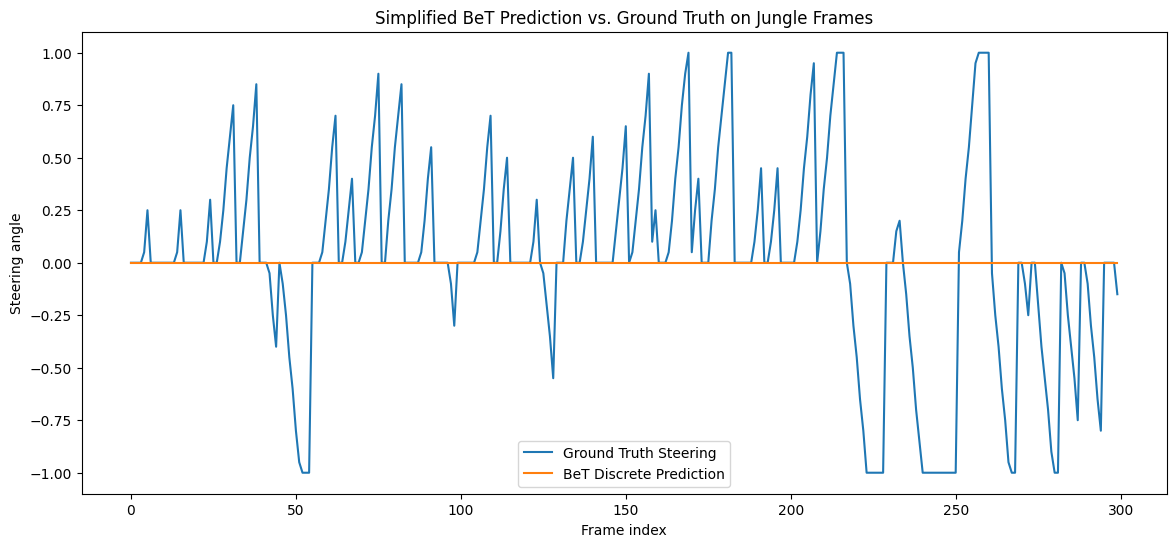

In [33]:
# task 11
# plot
plt.figure(figsize=(14, 6))
plt.plot(
    ground_truth,
    label="Ground Truth Steering"
)
plt.plot(
    bet_predictions,
    label="BeT Discrete Prediction"
)
plt.title(
    "Simplified BeT Prediction vs. Ground Truth on Jungle Frames"
)
plt.xlabel("Frame index")
plt.ylabel("Steering angle")
plt.legend()
plt.show()

### Task 11 answer
Analysis: Does your prediction line look smooth or "steppy"? Explain mathematically why discretizing the continuous action space without a residual offset causes this specific visual and physical behavior. How does your graph prove the necessity of the "residual action" head proposed by the authors in the BeT paper?


answer:
The prediction line looks very “steppy” because the model can only output one of the 10 fixed steering cluster centers instead of a continuous range of steering values. Mathematically, the continuous steering space is discretized into a small set of bins, so many slightly different steering angles are forced to map to the same output value. Therefore, the prediction stays flat for many frames and then suddenly experiences a jump when the predicted class changes.

This creates unrealistic driving behavior because steering in real driving changes continuously rather than in fixed steps. The graph demonstrates why the residual action head proposed in the BeT paper is necessary. The discrete action bin can capture the general steering direction, but without a residual offset, the model cannot make fine adjustments within each bin. A residual action head would allow the model to predict small continuous corrections on top of the discrete action center, producing smoother and more accurate steering trajectories.